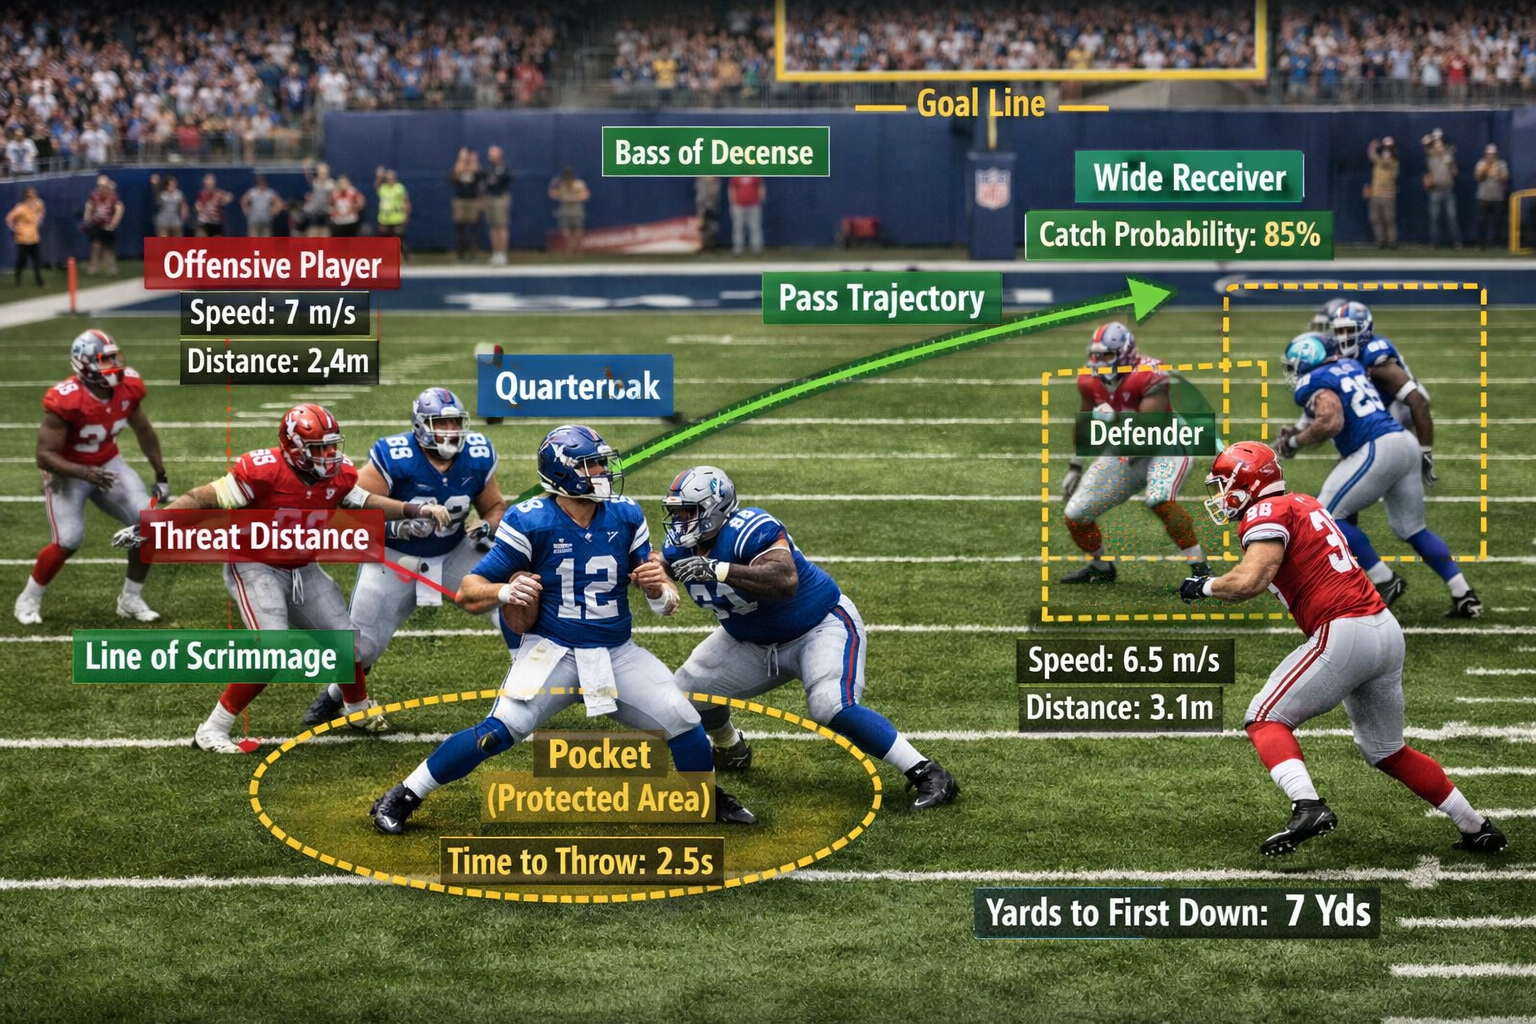

# NFL Kaggle dataset

In [1]:
#%pip install kagglehub

In [ ]:
import os
import numpy as np
import pandas as pd
import kagglehub
from kagglehub import KaggleDatasetAdapter

In [ ]:
# baixa o dataset do KaggleHub e retorna o caminho local onde os arquivos foram armazenados
root = kagglehub.dataset_download("maxhorowitz/nflplaybyplay2009to2016") 
print("Root:", root)

In [4]:
for dirpath, dirnames, filenames in os.walk(root):  # percorre recursivamente todas as pastas dentro do diretório root
    for f in filenames:  # itera sobre cada arquivo encontrado em cada pasta
        print(os.path.relpath(os.path.join(dirpath, f), root))  # imprime o caminho relativo de cada arquivo em relação ao diretório root

NFL Play by Play 2009-2016 (v3).csv
NFL Play by Play 2009-2017 (v4).csv
NFL Play by Play 2009-2018 (v5).csv


In [ ]:
# Exemplo: ajuste para o arquivo real que você viu no os.walk
csv_path = os.path.join(root, "NFL Play by Play 2009-2017 (v4).csv") # cria o caminho completo para o arquivo CSV dentro do diretório root
df = pd.read_csv(csv_path) # lê o arquivo CSV e carrega os dados em um DataFrame do pandas

In [6]:
df.head()

,Date,GameID,Drive,qtr,down,time,TimeUnder,TimeSecs,PlayTimeDiff,SideofField,...,yacEPA,Home_WP_pre,Away_WP_pre,Home_WP_post,Away_WP_post,Win_Prob,WPA,airWPA,yacWPA,Season
0,2009-09-10,2009091000,1,1,NaN,15:00,15,3600.0,0.0,TEN,...,NaN,0.485675,0.514325,0.546433,0.453567,0.485675,0.060758,NaN,NaN,2009
1,2009-09-10,2009091000,1,1,1.0,14:53,15,3593.0,7.0,PIT,...,1.146076,0.546433,0.453567,0.551088,0.448912,0.546433,0.004655,-0.032244,0.036899,2009
2,2009-09-10,2009091000,1,1,2.0,14:16,15,3556.0,37.0,PIT,...,NaN,0.551088,0.448912,0.510793,0.489207,0.551088,-0.040295,NaN,NaN,2009
3,2009-09-10,2009091000,1,1,3.0,13:35,14,3515.0,41.0,PIT,...,-5.031425,0.510793,0.489207,0.461217,0.538783,0.510793,-0.049576,0.106663,-0.156239,2009
4,2009-09-10,2009091000,1,1,4.0,13:27,14,3507.0,8.0,PIT,...,NaN,0.461217,0.538783,0.558929,0.441071,0.461217,0.097712,NaN,NaN,2009


In [7]:
df.info(verbose=True)  # exibe informações completas do DataFrame, incluindo todas as colunas, tipos de dados e valores não nulos
# O parâmetro verbose=True no df.info() serve para forçar a exibição detalhada
# de todas as colunas do DataFrame, independentemente do tamanho.

<class 'pandas.DataFrame'>
RangeIndex: 407688 entries, 0 to 407687
Data columns (total 102 columns):
 #    Column                       Dtype  
---   ------                       -----  
 0    Date                         str    
 1    GameID                       int64  
 2    Drive                        int64  
 3    qtr                          int64  
 4    down                         float64
 5    time                         str    
 6    TimeUnder                    int64  
 7    TimeSecs                     float64
 8    PlayTimeDiff                 float64
 9    SideofField                  str    
 10   yrdln                        float64
 11   yrdline100                   float64
 12   ydstogo                      int64  
 13   ydsnet                       int64  
 14   GoalToGo                     float64
 15   FirstDown                    float64
 16   posteam                      str    
 17   DefensiveTeam                str    
 18   desc                         str 

### O que o DtypeWarning está dizendo? 
`Columns (25,51) have mixed types.`

Significa que, nas colunas de índice 25 e 51:

- Parte dos valores parece numérica

- Parte dos valores parece texto

- O pandas não conseguiu inferir um único dtype de forma segura

Por padrão, o `read_csv` lê o arquivo em chunks para economizar memória (`low_memory=True`), o que aumenta a chance desse aviso.

Alternativamente, pode-se ler o conjunto de dados como:
`df = pd.read_csv(csv_path, low_memory=False)`

Isso força leitura em uma única passada e reduz falsos positivos de inferência.

---
### Importante:
Em uma etapa de Análise Exploratória de Dados, sempre investique os alertas do tipo `DtypeWarning`
- Neste caso, vamos identificar e inspecionar essas colunas:

#### Identificando:

In [8]:
problem_cols = df.columns[[25, 51]]
problem_cols

Index(['DefTwoPoint', 'BlockingPlayer'], dtype='str')

#### Inspecionando:

In [9]:
df[problem_cols[0]].apply(type).value_counts()
# aplica a função type em cada valor da coluna problem_cols[0] e conta quantas ocorrências existem de cada tipo de dado

DefTwoPoint
<class 'float'>    407664
<class 'str'>          24
Name: count, dtype: int64

In [10]:
df[problem_cols[1]].apply(type).value_counts()

BlockingPlayer
<class 'float'>    407571
<class 'str'>         117
Name: count, dtype: int64

- Inspecionando dados do tipo `str`

In [11]:
df.loc[df[problem_cols[0]].apply(type) == str, problem_cols[0]] # filtra apenas os valores da coluna problem_cols[0] cujo tipo é string (str)
#df.loc[df[problem_cols[0]].apply(type) == str] # Ver todos os dados da linha

278907    Failure
284977    Failure
286715    Failure
301227    Failure
304879    Success
321075    Success
323901    Failure
341248    Success
342856    Failure
345982    Failure
348856    Success
351968    Success
352569    Failure
359061    Failure
362769    Failure
368022    Failure
372456    Failure
381748    Failure
385310    Failure
386506    Failure
390624    Failure
403182    Failure
404890    Failure
406623    Failure
Name: DefTwoPoint, dtype: str

In [12]:
df.loc[df[problem_cols[1]].apply(type) == str, problem_cols[1]]

1425            J.McGraw
2779          B.Williams
16313           J.Hester
21255            G.Hayes
27429            E.Smith
               ...      
390149         S.Barrett
394443            T.Fede
398604          M.Thomas
400907    K.Grugier-Hill
402225          A.Walker
Name: BlockingPlayer, Length: 117, dtype: str

- Inspecionando dados do tipo `float`

In [13]:
df.loc[df[problem_cols[0]].apply(type) == float, problem_cols[0]].head()

0    NaN
1    NaN
2    NaN
3    NaN
4    NaN
Name: DefTwoPoint, dtype: str

In [14]:
df.loc[df[problem_cols[1]].apply(type) == float, problem_cols[1]].head()

0    NaN
1    NaN
2    NaN
3    NaN
4    NaN
Name: BlockingPlayer, dtype: str

- Inpecionando dados únicos

In [15]:
df[problem_cols[0]].unique()

<ArrowStringArray>
[nan, 'Failure', 'Success']
Length: 3, dtype: str

In [16]:
df[problem_cols[1]].unique()

<ArrowStringArray>
[             nan,       'J.McGraw',     'B.Williams',       'J.Hester',
        'G.Hayes',        'E.Smith',        'C.Lynch',        'G.Hardy',
     'R.Jennings',        'D.Curry',
 ...
     'C.Reynolds',   'T.Matakevich',    'C.Littleton',       'J.Willis',
       'J.Hardee',     'R.Burkhead',      'S.Barrett',       'M.Thomas',
 'K.Grugier-Hill',       'A.Walker']
Length: 102, dtype: str

- Contagem de `NaN`

In [17]:
for cols in df[problem_cols]:
    print("Total de NaN em",cols,":",df[cols].isna().sum())

Total de NaN em DefTwoPoint : 407664
Total de NaN em BlockingPlayer : 407571


## O que fazer agora?

In [18]:
# 1) Incialmente não precisa fazer nada, mas isso diminui a eficiência do algoritmo, 
# pois o Pandas tenta otimizar memória com leitura em blocos do mesmo tipo.
# 2) Poderia converter tudo para Object, mas isso apenas empurraria o problema para frente
# - Object é um estado intermediário, não destino
# - Object é um contêiner genérico do Python. 
# - Indica ausência de tipagem clara.
# - Deve ser resolvido no pipeline

# Converte tudo para category
df[problem_cols[0]] = df[problem_cols[0]].astype("category")  
# converte a coluna problem_cols[0] para o tipo string do pandas, 
# padronizando o formato textual e preservando valores ausentes como <NA>

In [19]:
# Trata como variável categórica e deixa claro que o resto é ausência
df[problem_cols[0]].value_counts(dropna=False)  
# conta quantas vezes cada valor aparece na coluna problem_cols[0], incluindo também os valores ausentes (NaN)

DefTwoPoint
NaN        407664
Failure        19
Success         5
Name: count, dtype: int64

In [20]:
# Converte tudo para string
df[problem_cols[1]] = df[problem_cols[1]].astype("string")  
# converte a coluna problem_cols[1] para o tipo string do pandas, permitindo melhor tratamento de textos e valores ausentes (NaN)

In [21]:
# Trata como variável categórica e deixa claro que o resto é ausência
df[problem_cols[1]].value_counts(dropna=False)  
# conta a frequência de cada valor da coluna problem_cols[1], incluindo também os valores NaN

BlockingPlayer
<NA>              407571
R.Jennings             3
B.Braman               3
D.Watson               3
E.Smith                2
                   ...  
R.Burkhead             1
S.Barrett              1
M.Thomas               1
K.Grugier-Hill         1
A.Walker               1
Name: count, Length: 102, dtype: int64[pyarrow]

In [22]:
df.info(verbose=True)

<class 'pandas.DataFrame'>
RangeIndex: 407688 entries, 0 to 407687
Data columns (total 102 columns):
 #    Column                       Dtype   
---   ------                       -----   
 0    Date                         str     
 1    GameID                       int64   
 2    Drive                        int64   
 3    qtr                          int64   
 4    down                         float64 
 5    time                         str     
 6    TimeUnder                    int64   
 7    TimeSecs                     float64 
 8    PlayTimeDiff                 float64 
 9    SideofField                  str     
 10   yrdln                        float64 
 11   yrdline100                   float64 
 12   ydstogo                      int64   
 13   ydsnet                       int64   
 14   GoalToGo                     float64 
 15   FirstDown                    float64 
 16   posteam                      str     
 17   DefensiveTeam                str     
 18   desc         

### Tipagem de dados

#### 1. Tipo técnico

O **tipo técnico** responde à pergunta:

> “Como esse dado está armazenado e processado pelo computador?”

O tipo técnico é definido pela ferramenta, linguagem ou biblioteca.

Exemplos em pandas:

- object
- float64
- int64
- bool
- datetime64
- string
- category

Esses tipos dizem respeito a:

- uso de memória
- velocidade de operação
- representação interna
- compatibilidade com funções

Isso só informa como o dado está guardado, não o que ele representa.

#### 2. Tipo semântico

O **tipo semântico** responde à pergunta:

> “O que esse dado representa no mundo real?”

Ele é definido pelo significado do atributo, não pela ferramenta.

Exemplos de tipos semânticos:

- idade
- identificador
- categoria
- rótulo
- texto livre
- código
- data de evento
- variável contínua
- variável discreta
- variável ordinal

Exemplo:

- idade é uma variável quantitativa discreta
- cpf é um identificador, não um número
- sexo é categórico nominal
- nota pode ser ordinal
- preço é quantitativo contínuo

#### 3. Onde ocorre a confusão

Um dataset não carrega semântica. Ele só armazena dados.

Quando o pandas lê um CSV, ele tenta inferir tipos técnicos, não semânticos.

**Exemplo clássico:**
    
| cpf          |
|--------------|
| 01234567890  |
| 12345678901  |
| 98765432100  |

- O Pandas tenta iferir: `cpf = int64`
- Tecnicamente correto, semanticamente errado.
- CPF não é número. É um identificador.

---
#### Exemplos e correções
##### Exemplo 1: CPF
- Tipo técnico inferido: int64
- Tipo semântico correto: identificador categórico

Correção: `df["cpf"] = df["cpf"].astype("string")`

---
##### Exemplo 2: Sexo
- Tipo técnico inferido: object
- Tipo semântico correto: categórico nominal

Correção: `df["sexo"] = df["sexo"].astype("category")`

--- 
##### Exemplo 3: Preço

- Tipo técnico inferido: float64
- Tipo semântico correto: variável contínua

Aqui há alinhamento. Nenhuma correção é necessária.

--- 
##### Exemplo 4. Data como texto

- Tipo técnico inferido: object
- Tipo semântico correto: data temporal

Correção:`df["data"] = pd.to_datetime(df["data"])` 

### Por que isso importa tanto

Quando tipo técnico e semântico estão desalinhados:
- estatísticas ficam erradas
- modelos aprendem padrões inexistentes
- comparações não fazem sentido
- ordenações ficam incorretas
- decisões analíticas se tornam inválidas

> O tipo técnico deve ser consequência do tipo semântico, nunca o contrário.

#### Fluxo correto para definir tipagem em atividades de modelagem:

1. Entender o significado do atributo
2. Classificar semanticamente
3. Escolher o tipo técnico adequado
4. Codificar no DataFrame

### Regra 
Neste contexto, é importante entender que `object` é um estado intermediário, não um destino.

Depois do EDA, cada coluna deveria ser:

- numérica(`int`, `float`)
- categórica(`category`)
- texto(`string`)
- temporal(`datetime`)
- lógica(`bool`)

---
Vamos analisar os tipos deste dataset

In [23]:
df.dtypes.value_counts()  # conta quantas colunas existem de cada tipo de dado (int, float, object, etc.) no DataFrame

str         36
float64     33
int64       31
category     1
string       1
Name: count, dtype: int64

### Importante:

`string` e `str` não são a mesma coisa no pandas, mesmo que pareçam semelhantes.

Essa é uma distinção fundamental entre tipo técnico Python e tipo técnico pandas.

- `astype("string")`: converte para StringDtype do pandas
- `astype(str)`: converte cada valor para objeto Python str

Resultado:

- `string`: dtype = string
- `str`: dtype = object

Analogia:
- `str` é tipo de valor
- `string` é tipo de coluna

Converter valores não muda automaticamente a estrutura do container.

#### Diferença no tratamento de valores ausentes
##### Com `str`

- None: "None"
- NaN: "nan"
 
Perde semântica de ausência.

##### Com `string`
- None: `<NA>`
- NaN: `<NA>`

Ausência é preservada corretamente.

---
#### Regra prática 

- Converter para texto semântico: use `string`
- Nunca use `str` para tipagem estrutural
- `str` é apenas uma função de conversão de valores
- `str` atua nos valores
- `string` atua na coluna
- `object` é container genérico
- `string` é tipo semântico de texto

# Continuando 
---
## Análise de valores ausentes
Objetivo: medir ausência real, não artefatos.

In [24]:
#pd.set_option("display.max_rows", None)  # configura o pandas para mostrar todas as linhas na saída, sem truncamento
df.isna().sum()  # calcula e mostra a quantidade de valores ausentes (NaN) em cada coluna do DataFrame

Date             0
GameID           0
Drive            0
qtr              0
down         61154
             ...  
Win_Prob     25009
WPA           5541
airWPA      248501
yacWPA      248762
Season           0
Length: 102, dtype: int64

## Limitações:
#### O que `isna()` realmente detecta

O pandas considera como ausência formal apenas:

- `NaN` (np.nan)
- `None`
- `pd.NA`
- `NaT` (para datas)

#### O que `isna()` NÃO detecta

O pandas **não considera ausentes** valores como:

- strings vazias ""
- strings com espaço " "
- textos como "NA", "N/A", "null", "None", "nan"
- valores sentinela como -1, 0, 9999
- datas inválidas convertidas para string
- categorias como "unknown", "missing"

Esses valores são **semanticamente ausentes**, mas **tecnicamente válidos**.

### Como detectar outros “ausentes semânticos”
##### Strings vazias ou espaços

In [25]:
(df == "").sum()

Date        0.0
GameID      0.0
Drive       0.0
qtr         0.0
down        0.0
           ... 
Win_Prob    0.0
WPA         0.0
airWPA      0.0
yacWPA      0.0
Season      0.0
Length: 102, dtype: double[pyarrow]

#### Textos que representam ausência

In [26]:
missing_tokens = ["NA", "N/A", "null", "None", "nan", "UNKNOWN"]

df.isin(missing_tokens).sum()

Date        0
GameID      0
Drive       0
qtr         0
down        0
           ..
Win_Prob    0
WPA         0
airWPA      0
yacWPA      0
Season      0
Length: 102, dtype: int64

#### Valores sentinela numéricos (Exige conhecimento do domínio, não há função genérica.)
Exemplo com -1 ou 0:

In [27]:
((df == -1) | (df == 0)).sum()

Date            0.0
GameID          0.0
Drive           0.0
qtr             0.0
down            0.0
             ...   
Win_Prob      189.0
WPA         33439.0
airWPA         14.0
yacWPA      23397.0
Season          0.0
Length: 102, dtype: double[pyarrow]

#### Datas inválidas
Datas mal parseadas ficam como texto:

In [28]:
df['time'].isna().sum() # conta quantos valores ausentes (NaN) existem na coluna 'time'

np.int64(224)

In [ ]:
pd.to_datetime(df['time'], errors="coerce").isna().sum()
# tenta converter a coluna 'time' para datetime, transforma valores inválidos em NaT e conta quantos não puderam ser convertidos

In [30]:
df['time'].isna().sum()

np.int64(224)

##### Se o número crescer após o parse, havia datas inválidas

#### Importante:
Analisar valores ausentes antes da tipagem, corre o risco de:

- contar "nan" como valor válido
- não detectar ausência real
- distorcer percentuais


### Decisão sobre tratamento de missing

Agora sim, decisões.

Objetivo:
- imputar
- descartar
- criar flags
- manter como NA

Aqui o tipo técnico já precisa estar correto.

### Exercício:
Analise as demais variáveis, transforme as colunas do tipo `Object` em tipo técnico. 

### Importante:
- Olhar o dicionário dos dados, quando houver, ajuda muito.
- Inferir o dicionário a partir dos dados (engenharia reversa) é muito mais difícil, mas as vezes é o único caminho possível.

Dicionário disponibiizado:
- https://github.com/maksimhorowitz/nflscrapR/blob/master/R/scrape_play_by_play.R
- A partir de "\item{play_id}", você pode ver a descrição de cada variável extraída.

### Para iniciar a transformação, filtre todas as colunas do tipo object

In [31]:
df.select_dtypes(include=("str")).dtypes

Date                   str
time                   str
SideofField            str
posteam                str
DefensiveTeam          str
desc                   str
ExPointResult          str
TwoPointConv           str
PuntResult             str
PlayType               str
Passer                 str
Passer_ID              str
PassOutcome            str
PassLength             str
PassLocation           str
Interceptor            str
Rusher                 str
Rusher_ID              str
RunLocation            str
RunGap                 str
Receiver               str
Receiver_ID            str
ReturnResult           str
Returner               str
BlockingPlayer      string
Tackler1               str
Tackler2               str
FieldGoalResult        str
RecFumbTeam            str
RecFumbPlayer          str
ChalReplayResult       str
PenalizedTeam          str
PenaltyType            str
PenalizedPlayer        str
HomeTeam               str
AwayTeam               str
Timeout_Team           str
d

In [32]:
# Date
print(pd.to_datetime(df["Date"], errors="coerce").isna().sum()) # Todos os dados foram transformados, ele não muda, apenas printa

df["Date"] = df["Date"].astype("datetime64[s]")


0


In [33]:
print(df["Date"].dtype)

datetime64[s]


In [37]:
# time
df["time"] = df["time"].astype("string")
df["time"].dtypes

<StringDtype(na_value=<NA>)>